# FootShellGaussian Foot Prior Alignment Playground

This notebook is for understanding the first foot-prior step before training.

It loads:

- the reconstructed GShell shoe mesh
- the watertight GShell mesh
- the neutral SUPR right-foot mesh
- the SUPR-foot SDF grid

Then it aligns the foot inside the shoe and colors shoe regions using the foot SDF.

Nothing in this notebook trains a model. This is a diagnostic and visualization notebook.


In [1]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "5")

from pathlib import Path
import sys
import json

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

FOOTSHELL_ROOT = Path("/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian")
PROJECT_ROOT = FOOTSHELL_ROOT.parent
if str(FOOTSHELL_ROOT) not in sys.path:
    sys.path.insert(0, str(FOOTSHELL_ROOT))

# Jupyter keeps imported modules alive across cell edits. Reload the local package
# so newly added helpers in foot_prior/__init__.py are visible without a kernel restart.
import importlib
import foot_prior as _foot_prior
import foot_prior.foot_alignment as _foot_alignment
importlib.reload(_foot_alignment)
importlib.reload(_foot_prior)

from foot_prior import (
    FootAlignmentConfig,
    FootSDFGrid,
    MeshData,
    build_alignment_from_meshes,
    classify_shoe_points,
    colors_from_regions,
    detect_shoe_opening_boundary,
    get_single_boundary_loop,
    load_triangle_mesh,
    make_hybrid_mesh,
    mesh_bounds,
    principal_yaw_degrees,
    region_summary,
    select_faces_below_axis,
    select_faces_below_signed_axis,
    write_colored_ply,
    write_obj_mesh,
)

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


torch: 1.13.1 cuda: True
GPU: NVIDIA A100-SXM4-80GB


## 1. Paths

Start with the shoe we already debugged. Later I can change `SHOE_NAME`, `SHELL_MESH_PATH`, or `WATERTIGHT_MESH_PATH` to inspect another reconstruction.


In [2]:
SHOE_NAME = "Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids"
DATASET_SCENE = Path("/data/abelde/datasets/processed/gshell_shoes/canonical") / SHOE_NAME
GSHELL_DEBUG_OUTPUT = PROJECT_ROOT / "baselines" / "GShell" / "output" / f"{SHOE_NAME}_sole_debug"

SHELL_MESH_PATH = GSHELL_DEBUG_OUTPUT / "mesh" / "mesh.obj"
WATERTIGHT_MESH_PATH = GSHELL_DEBUG_OUTPUT / "mesh_watertight" / "mesh.obj"
FOOT_OBJ_PATH = PROJECT_ROOT / "baselines" / "SUPR" / "output" / "debug_playground" / "supr_male_right_foot_neutral.obj"
FOOT_SDF_PATH = FOOTSHELL_ROOT / "data" / "foot_prior" / "supr_male_right_foot_sdf.npz"
OUT_DIR = FOOTSHELL_ROOT / "output" / "foot_prior_debug" / SHOE_NAME

for label, path in {
    "dataset scene": DATASET_SCENE,
    "shell mesh": SHELL_MESH_PATH,
    "watertight mesh": WATERTIGHT_MESH_PATH,
    "foot OBJ": FOOT_OBJ_PATH,
    "foot SDF": FOOT_SDF_PATH,
}.items():
    print(f"{label:16s}: {path} | exists={path.exists()}")


dataset scene   : /data/abelde/datasets/processed/gshell_shoes/canonical/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids | exists=False
shell mesh      : /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_sole_debug/mesh/mesh.obj | exists=True
watertight mesh : /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_sole_debug/mesh_watertight/mesh.obj | exists=True
foot OBJ        : /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/output/debug_playground/supr_male_right_foot_neutral.obj | exists=True
foot SDF        : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/data/foot_prior/supr_male_right_foot_sdf.npz | exists=True


## 2. Load Meshes And SDF

The shell mesh is the mSDF-cut surface. The watertight mesh is the underlying closed surface before the mSDF cutting creates openings/holes.


In [3]:
shell_mesh = load_triangle_mesh(SHELL_MESH_PATH)
watertight_mesh = load_triangle_mesh(WATERTIGHT_MESH_PATH)
foot_mesh = load_triangle_mesh(FOOT_OBJ_PATH)
foot_sdf = FootSDFGrid.from_npz(str(FOOT_SDF_PATH), device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

print("shell mesh:     ", shell_mesh.vertices.shape, shell_mesh.faces.shape)
print("watertight mesh:", watertight_mesh.vertices.shape, watertight_mesh.faces.shape)
print("foot mesh:      ", foot_mesh.vertices.shape, foot_mesh.faces.shape)
print("foot SDF grid:  ", tuple(foot_sdf.sdf.shape), "bounds", foot_sdf.bounds_min.detach().cpu().numpy(), foot_sdf.bounds_max.detach().cpu().numpy())


shell mesh:      (2005, 3) (3052, 3)
watertight mesh: (1616, 3) (3228, 3)
foot mesh:       (266, 3) (515, 3)
foot SDF grid:   (1, 1, 128, 128, 128) bounds [-0.19143257 -1.3869797  -0.14568643] [-0.02844138 -1.2218517   0.18629017]


In [4]:
def print_bounds(name, vertices):
    mn, mx, size, center = mesh_bounds(vertices)
    print(name)
    print("  min:   ", mn)
    print("  max:   ", mx)
    print("  size:  ", size)
    print("  center:", center)

print_bounds("shell", shell_mesh.vertices)
print_bounds("watertight", watertight_mesh.vertices)
print_bounds("raw SUPR foot", foot_mesh.vertices)


shell
  min:    [-0.14739399 -0.06755324 -0.06746243]
  max:    [0.14367275 0.07245061 0.05416977]
  size:   [0.29106674 0.14000386 0.1216322 ]
  center: [-0.00186062  0.00244868 -0.00664633]
watertight
  min:    [-0.14739399 -0.06755324 -0.06746243]
  max:    [0.14367275 0.07327574 0.05416977]
  size:   [0.29106674 0.140829   0.1216322 ]
  center: [-0.00186062  0.00286125 -0.00664633]
raw SUPR foot
  min:    [-0.16143256 -1.3569797  -0.11568644]
  max:    [-0.05844138 -1.2518517   0.15629017]
  size:   [0.10299119 0.10512805 0.27197662]
  center: [-0.10993697 -1.3044157   0.02030187]


## 3. Plot Helpers

The plot uses GShell shoe coordinates directly. The foot is transformed into the same coordinates by the alignment object.


In [5]:
def _sample_faces(mesh, max_faces=2500):
    faces = mesh.faces
    if faces.shape[0] <= max_faces:
        return faces
    idx = np.linspace(0, faces.shape[0] - 1, max_faces).astype(np.int64)
    return faces[idx]


def display_axis_order(alignment=None):
    cfg = alignment.config if alignment is not None else FootAlignmentConfig()
    return [cfg.shoe_length_axis, cfg.shoe_width_axis, cfg.shoe_up_axis]


def display_axis_signs(alignment=None):
    cfg = alignment.config if alignment is not None else FootAlignmentConfig()
    return np.asarray([cfg.shoe_length_sign, cfg.shoe_width_sign, cfg.shoe_up_sign], dtype=np.float32)


def to_display_coords(vertices, alignment=None):
    vertices = np.asarray(vertices)
    return vertices[:, display_axis_order(alignment)] * display_axis_signs(alignment)[None, :]


def set_axes_equal(ax, vertices_list):
    all_vertices = np.concatenate([np.asarray(v).reshape(-1, 3) for v in vertices_list if np.asarray(v).size], axis=0)
    mn = all_vertices.min(axis=0)
    mx = all_vertices.max(axis=0)
    center = (mn + mx) * 0.5
    radius = max((mx - mn).max() * 0.55, 1e-6)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
        ax.set_proj_type("ortho")
    except Exception:
        pass


def add_mesh(ax, mesh, color="#9ecae1", alpha=0.55, max_faces=2500, linewidth=0.08, alignment=None):
    faces = _sample_faces(mesh, max_faces=max_faces)
    vertices_display = to_display_coords(mesh.vertices, alignment)
    poly = Poly3DCollection(vertices_display[faces], alpha=alpha, linewidths=linewidth)
    poly.set_facecolor(color)
    poly.set_edgecolor("#222222")
    ax.add_collection3d(poly)
    return vertices_display


def plot_alignment(alignment, elev=10, azim=-70, show_shell=True, show_watertight=True, title="aligned foot inside shoe"):
    foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
    aligned_mesh = MeshData(foot_aligned, foot_mesh.faces)

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    vertices_for_bounds = []

    if show_watertight:
        vertices_for_bounds.append(add_mesh(ax, watertight_mesh, color="#bdbdbd", alpha=0.18, max_faces=2500, linewidth=0.05, alignment=alignment))
    if show_shell:
        vertices_for_bounds.append(add_mesh(ax, shell_mesh, color="#74add1", alpha=0.38, max_faces=3500, linewidth=0.05, alignment=alignment))

    vertices_for_bounds.append(add_mesh(ax, aligned_mesh, color="#fdae6b", alpha=0.82, max_faces=900, linewidth=0.22, alignment=alignment))

    cfg = alignment.config
    opening = detect_shoe_opening_boundary(shell_mesh, cfg)
    if opening is not None:
        opening_vertices = shell_mesh.vertices[np.asarray(opening["vertices"], dtype=np.int64)]
        opening_display = to_display_coords(opening_vertices, alignment)
        ax.scatter(
            opening_display[:, 0],
            opening_display[:, 1],
            opening_display[:, 2],
            color="#542788",
            s=12,
            depthshade=False,
        )

    ankle_loop = alignment.transform_foot_to_shoe(foot_mesh.vertices[get_single_boundary_loop(foot_mesh)])
    ankle_loop_display = to_display_coords(np.concatenate([ankle_loop, ankle_loop[:1]], axis=0), alignment)
    ax.plot(ankle_loop_display[:, 0], ankle_loop_display[:, 1], ankle_loop_display[:, 2], color="#d73027", linewidth=2.0)

    shoe_min, shoe_max, _, _ = mesh_bounds(watertight_mesh.vertices)
    corners = np.zeros((5, 3), dtype=np.float32)
    corners[:, cfg.shoe_length_axis] = [shoe_min[cfg.shoe_length_axis], shoe_max[cfg.shoe_length_axis], shoe_max[cfg.shoe_length_axis], shoe_min[cfg.shoe_length_axis], shoe_min[cfg.shoe_length_axis]]
    corners[:, cfg.shoe_width_axis] = [shoe_min[cfg.shoe_width_axis], shoe_min[cfg.shoe_width_axis], shoe_max[cfg.shoe_width_axis], shoe_max[cfg.shoe_width_axis], shoe_min[cfg.shoe_width_axis]]
    corners[:, cfg.shoe_up_axis] = alignment.plantar_z + cfg.plantar_band * _foot_alignment.axis_sign(cfg.shoe_up_sign)
    corners_display = to_display_coords(corners, alignment)
    ax.plot(corners_display[:, 0], corners_display[:, 1], corners_display[:, 2], color="#2166ac", linewidth=1.5)

    set_axes_equal(ax, vertices_for_bounds)
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## 4. Default Principal-Axis Alignment

The corrected raw shoe coordinate model for this scene is:

```text
GShell X = shoe length
GShell Y = shoe height / opening-to-sole axis
GShell Z = shoe width
```

The missing sole/base is on the `+Y` side of this raw shell, so anatomical foot-up maps to `-Y`:

```text
SUPR +Z toes      -> GShell +X
SUPR +Y ankle/up  -> GShell -Y
SUPR -Y sole      -> GShell +Y
SUPR +X width     -> GShell +Z
```

The detector now skips the large missing-sole boundary before selecting the purple collar/opening boundary. The notebook display flips the signed height axis so the opening/up side appears visually upward in the plots.


In [6]:
def make_alignment(
    length_ratio=0.78,
    scale_multiplier=1.0,
    plantar_clearance=0.032,
    plantar_band=0.012,
    surface_band=0.005,
    clearance=0.005,
    ankle_radius=0.025,
    shoe_length_axis=0,
    shoe_up_axis=1,
    shoe_width_axis=2,
    shoe_length_sign=1.0,
    shoe_up_sign=-1.0,
    shoe_width_sign=1.0,
    auto_yaw=True,
    align_ankle_to_opening=True,
    yaw_degrees=0.0,
    pitch_degrees=0.0,
    roll_degrees=0.0,
    tx=0.0,
    ty=0.0,
    tz=0.0,
):
    config = FootAlignmentConfig(
        length_ratio=length_ratio,
        scale_multiplier=scale_multiplier,
        plantar_clearance=plantar_clearance,
        plantar_band=plantar_band,
        surface_band=surface_band,
        clearance=clearance,
        ankle_radius=ankle_radius,
        shoe_length_axis=shoe_length_axis,
        shoe_up_axis=shoe_up_axis,
        shoe_width_axis=shoe_width_axis,
        shoe_length_sign=shoe_length_sign,
        shoe_up_sign=shoe_up_sign,
        shoe_width_sign=shoe_width_sign,
        align_ankle_to_opening=align_ankle_to_opening,
        auto_yaw=auto_yaw,
        yaw_degrees=yaw_degrees,
        pitch_degrees=pitch_degrees,
        roll_degrees=roll_degrees,
        translation_offset=(tx, ty, tz),
    )
    return build_alignment_from_meshes(foot_mesh=foot_mesh, shoe_mesh=watertight_mesh, opening_mesh=shell_mesh, config=config)

print("shoe principal yaw degrees in x-z length/width plane:", principal_yaw_degrees(watertight_mesh.vertices, length_axis=0, width_axis=2))
alignment = make_alignment()
print(json.dumps(alignment.to_dict(), indent=2)[:2200])
foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
print_bounds("aligned foot", foot_aligned)


def show_default_alignment(elev=10, azim=-70, show_shell=True, show_watertight=True):
    plot_alignment(
        alignment,
        elev=elev,
        azim=azim,
        show_shell=show_shell,
        show_watertight=show_watertight,
        title="Default aligned foot: principal-axis yaw + raised plantar clearance",
    )


try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    default_elev_w = widgets.IntSlider(value=10, min=-90, max=90, step=2, description="elevation")
    default_azim_w = widgets.IntSlider(value=-70, min=-180, max=180, step=5, description="azimuth")
    default_shell_w = widgets.Checkbox(value=True, description="shell")
    default_watertight_w = widgets.Checkbox(value=True, description="watertight")
    default_out = widgets.Output()

    def redraw_default_alignment(_=None):
        with default_out:
            clear_output(wait=True)
            print("Rotate this default alignment view using elevation/azimuth sliders.")
            show_default_alignment(
                elev=default_elev_w.value,
                azim=default_azim_w.value,
                show_shell=default_shell_w.value,
                show_watertight=default_watertight_w.value,
            )

    default_controls = widgets.VBox([
        widgets.HBox([default_elev_w, default_azim_w, default_shell_w, default_watertight_w]),
    ])
    for widget in [default_elev_w, default_azim_w, default_shell_w, default_watertight_w]:
        widget.observe(redraw_default_alignment, names="value")
    display(default_controls, default_out)
    redraw_default_alignment()
except Exception as exc:
    print("ipywidgets are not available here; showing the static default alignment view instead.")
    print(type(exc).__name__ + ":", exc)
    show_default_alignment()


shoe principal yaw degrees in x-z length/width plane: -6.60911216210538
{
  "foot_to_shoe": [
    [
      -0.09607548266649246,
      0.0,
      0.8292011022567749,
      -0.03869783505797386
    ],
    [
      0.0,
      -0.8347484469413757,
      0.0,
      -1.091460943222046
    ],
    [
      0.8292011022567749,
      0.0,
      0.09607548266649246,
      0.08957283198833466
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "shoe_to_foot": [
    [
      -0.13788002729415894,
      0.0,
      1.190004587173462,
      -0.11192774027585983
    ],
    [
      -0.0,
      -1.1979657411575317,
      -0.0,
      -1.307532787322998
    ],
    [
      1.190004587173462,
      0.0,
      0.13788002729415894,
      0.03370029851794243
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "scale": 0.8347484210259871,
  "plantar_z": 0.041275739669799805,
  "auto_yaw_degrees": -6.60911216210538,
  "config": {
    "length_ratio": 0.78,
    "scale_multiplier": 1.0

Output()

## 5. Turntable Views

Use these views to check whether the foot is actually sitting where a foot should sit: inside the upper and above the sole.


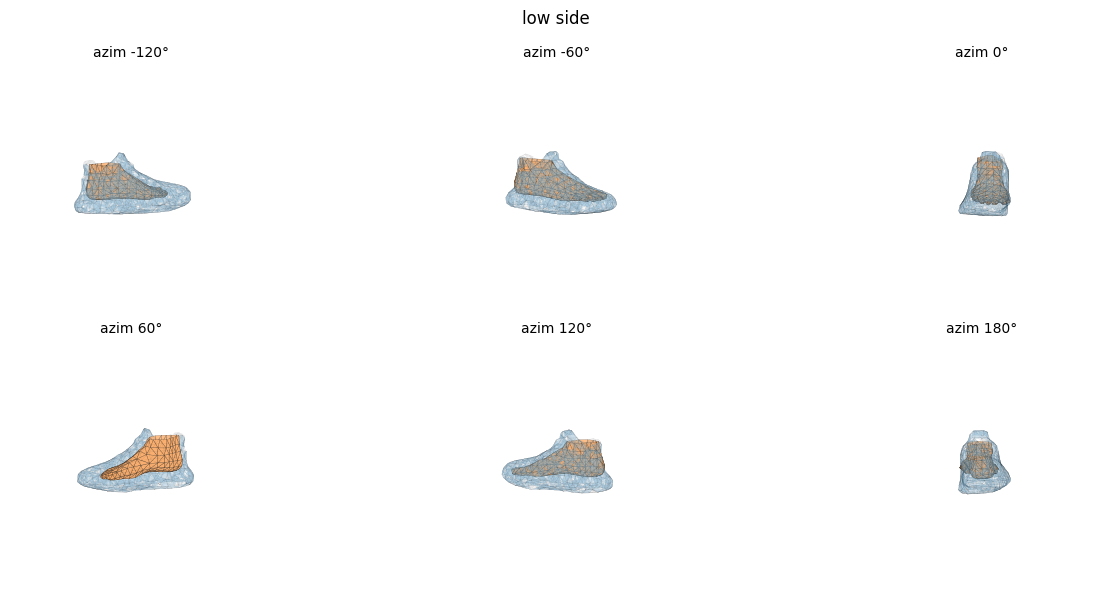

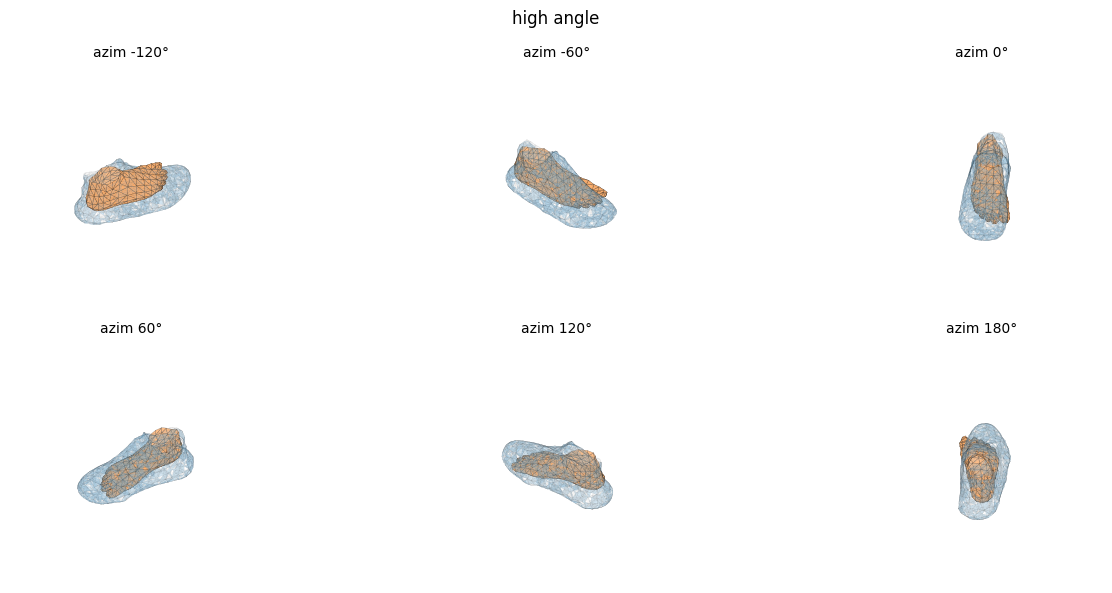

In [7]:
def plot_turntable(alignment):
    for elev, label in [(8, "low side"), (45, "high angle")]:
        fig = plt.figure(figsize=(14, 6))
        for i, azim in enumerate([-120, -60, 0, 60, 120, 180], start=1):
            ax = fig.add_subplot(2, 3, i, projection="3d")
            foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
            add_mesh(ax, watertight_mesh, color="#bdbdbd", alpha=0.16, max_faces=1800, linewidth=0.04, alignment=alignment)
            add_mesh(ax, shell_mesh, color="#74add1", alpha=0.32, max_faces=2500, linewidth=0.04, alignment=alignment)
            add_mesh(ax, MeshData(foot_aligned, foot_mesh.faces), color="#fdae6b", alpha=0.80, max_faces=900, linewidth=0.16, alignment=alignment)
            set_axes_equal(ax, [to_display_coords(watertight_mesh.vertices, alignment), to_display_coords(foot_aligned, alignment)])
            ax.view_init(elev=elev, azim=azim)
            ax.set_axis_off()
            ax.set_title(f"azim {azim}°", fontsize=10)
        fig.suptitle(label)
        plt.tight_layout()
        plt.show()

plot_turntable(alignment)


## 6. SDF Region Classification

Now we query the foot SDF at shoe **vertices**.

Interpretation:

```text
SDF < 0       : shoe vertex is inside the foot volume
SDF near 0    : shoe vertex is near the foot surface
SDF < 0.005   : clearance violation / too close to foot
below plantar : vertex is on the signed sole/material side of the plantar plane
near ankle    : vertex is near the ankle boundary loop
```

Important: the red-dot plots below are **vertex-only diagnostics**. They do not prove that the full base/insole surface is selected.


In [8]:
def classify_with_alignment(alignment):
    ankle_loop = alignment.transform_foot_to_shoe(foot_mesh.vertices[get_single_boundary_loop(foot_mesh)])
    shell_regions = classify_shoe_points(shell_mesh.vertices, foot_sdf, alignment, ankle_loop)
    watertight_regions = classify_shoe_points(watertight_mesh.vertices, foot_sdf, alignment, ankle_loop)
    print("shell vertices")
    print(json.dumps(region_summary(shell_regions), indent=2))
    print("\nwatertight vertices")
    print(json.dumps(region_summary(watertight_regions), indent=2))
    return shell_regions, watertight_regions

shell_regions, watertight_regions = classify_with_alignment(alignment)


shell vertices
{
  "num_points": 2005,
  "sdf_min": -0.013340315781533718,
  "sdf_max": 0.06605099886655807,
  "sdf_mean": 0.0291778352111578,
  "inside_foot_count": 39,
  "inside_foot_fraction": 0.01945137157107232,
  "near_foot_surface_count": 103,
  "near_foot_surface_fraction": 0.051371571072319204,
  "clearance_violation_count": 116,
  "clearance_violation_fraction": 0.05785536159600998,
  "below_plantar_count": 1188,
  "below_plantar_fraction": 0.5925187032418953,
  "near_ankle_count": 179,
  "near_ankle_fraction": 0.08927680798004987
}

watertight vertices
{
  "num_points": 1616,
  "sdf_min": -0.013340315781533718,
  "sdf_max": 0.06605099886655807,
  "sdf_mean": 0.027554187923669815,
  "inside_foot_count": 76,
  "inside_foot_fraction": 0.04702970297029703,
  "near_foot_surface_count": 115,
  "near_foot_surface_fraction": 0.07116336633663366,
  "clearance_violation_count": 143,
  "clearance_violation_fraction": 0.08849009900990099,
  "below_plantar_count": 873,
  "below_plantar_f

In [ ]:
REGION_KEYS = ["inside_foot", "clearance_violation", "below_plantar", "near_ankle"]


def plot_region_points(
    mesh,
    regions,
    key,
    title,
    elev=10,
    azim=-70,
    point_size=5,
    mesh_alpha=0.12,
    foot_alpha=0.35,
    show_mesh=True,
    show_foot=True,
):
    mask = np.asarray(regions[key], dtype=bool)
    points = mesh.vertices[mask]
    points_display = to_display_coords(points, alignment) if points.shape[0] > 0 else points

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    bounds_vertices = [to_display_coords(mesh.vertices, alignment)]

    if show_mesh:
        add_mesh(
            ax,
            mesh,
            color="#cccccc",
            alpha=mesh_alpha,
            max_faces=3500,
            linewidth=0.04,
            alignment=alignment,
        )

    if points.shape[0] > 0:
        ax.scatter(
            points_display[:, 0],
            points_display[:, 1],
            points_display[:, 2],
            s=point_size,
            c="#d7191c",
            depthshade=False,
        )

    if show_foot:
        foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
        add_mesh(
            ax,
            MeshData(foot_aligned, foot_mesh.faces),
            color="#fdae6b",
            alpha=foot_alpha,
            max_faces=900,
            linewidth=0.12,
            alignment=alignment,
        )
        bounds_vertices.append(to_display_coords(foot_aligned, alignment))

    set_axes_equal(ax, bounds_vertices)
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    ax.set_title(f"{title}: {int(mask.sum())} selected vertices")
    plt.tight_layout()
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    region_w = widgets.Dropdown(
        options=REGION_KEYS,
        value="below_plantar",
        description="region",
    )
    elev_w = widgets.IntSlider(value=10, min=-90, max=90, step=2, description="elevation")
    azim_w = widgets.IntSlider(value=-70, min=-180, max=180, step=5, description="azimuth")
    point_w = widgets.IntSlider(value=5, min=1, max=30, step=1, description="points")
    mesh_alpha_w = widgets.FloatSlider(value=0.12, min=0.0, max=1.0, step=0.02, description="mesh alpha")
    foot_alpha_w = widgets.FloatSlider(value=0.35, min=0.0, max=1.0, step=0.02, description="foot alpha")
    show_mesh_w = widgets.Checkbox(value=True, description="show shoe")
    show_foot_w = widgets.Checkbox(value=True, description="show foot")
    out = widgets.Output()

    def redraw_region_points(_=None):
        key = region_w.value
        with out:
            clear_output(wait=True)
            print("This is a vertex-only diagnostic. Red dots are selected watertight mesh vertices, not filled surface area.")
            print(f"region={key}, selected={int(np.asarray(watertight_regions[key]).sum())} / {watertight_mesh.vertices.shape[0]} vertices")
            print("Rotate using the elevation/azimuth sliders; the shoe, foot, and red points redraw together.")
            plot_region_points(
                watertight_mesh,
                watertight_regions,
                key,
                f"watertight selected vertices: {key}",
                elev=elev_w.value,
                azim=azim_w.value,
                point_size=point_w.value,
                mesh_alpha=mesh_alpha_w.value,
                foot_alpha=foot_alpha_w.value,
                show_mesh=show_mesh_w.value,
                show_foot=show_foot_w.value,
            )

    controls = widgets.VBox([
        widgets.HBox([region_w, elev_w, azim_w, point_w]),
        widgets.HBox([mesh_alpha_w, foot_alpha_w, show_mesh_w, show_foot_w]),
    ])
    for widget in [region_w, elev_w, azim_w, point_w, mesh_alpha_w, foot_alpha_w, show_mesh_w, show_foot_w]:
        widget.observe(redraw_region_points, names="value")
    display(controls, out)
    redraw_region_points()
except Exception as exc:
    print("ipywidgets are not available here, so showing static vertex-only views instead.")
    print(type(exc).__name__ + ":", exc)
    for key in REGION_KEYS:
        plot_region_points(watertight_mesh, watertight_regions, key, f"watertight selected vertices: {key}")


Output()

In [10]:
# Triangle/surface version of the red-dot diagnostic above.
# This answers a different question:
#   red dots     = which vertices/corner points are selected?
#   red triangles = which actual mesh faces are selected?

FACE_RULES = ["all 3 vertices", "2+ vertices", "any vertex"]


def face_mask_from_vertex_region(mesh, vertex_mask, rule="all 3 vertices"):
    vertex_mask = np.asarray(vertex_mask, dtype=bool)
    selected_per_face = vertex_mask[np.asarray(mesh.faces, dtype=np.int64)].sum(axis=1)
    if rule == "all 3 vertices":
        return selected_per_face == 3
    if rule == "2+ vertices":
        return selected_per_face >= 2
    if rule == "any vertex":
        return selected_per_face >= 1
    raise ValueError(f"Unknown face selection rule: {rule}")


def plot_region_faces(
    mesh,
    regions,
    key,
    title,
    face_rule="all 3 vertices",
    elev=10,
    azim=-70,
    selected_alpha=0.88,
    background_alpha=0.08,
    foot_alpha=0.25,
    show_background=True,
    show_foot=True,
    show_selected_vertices=False,
):
    vertex_mask = np.asarray(regions[key], dtype=bool)
    face_mask = face_mask_from_vertex_region(mesh, vertex_mask, face_rule)
    selected_faces = mesh.faces[face_mask]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    bounds_vertices = [to_display_coords(mesh.vertices, alignment)]

    if show_background:
        add_mesh(
            ax,
            mesh,
            color="#bdbdbd",
            alpha=background_alpha,
            max_faces=3500,
            linewidth=0.03,
            alignment=alignment,
        )

    if selected_faces.shape[0] > 0:
        add_mesh(
            ax,
            MeshData(mesh.vertices, selected_faces),
            color="#d7191c",
            alpha=selected_alpha,
            max_faces=selected_faces.shape[0],
            linewidth=0.08,
            alignment=alignment,
        )

    if show_selected_vertices and vertex_mask.sum() > 0:
        selected_points = to_display_coords(mesh.vertices[vertex_mask], alignment)
        ax.scatter(
            selected_points[:, 0],
            selected_points[:, 1],
            selected_points[:, 2],
            s=5,
            c="#54278f",
            depthshade=False,
        )

    if show_foot:
        foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
        add_mesh(
            ax,
            MeshData(foot_aligned, foot_mesh.faces),
            color="#fdae6b",
            alpha=foot_alpha,
            max_faces=900,
            linewidth=0.08,
            alignment=alignment,
        )
        bounds_vertices.append(to_display_coords(foot_aligned, alignment))

    set_axes_equal(ax, bounds_vertices)
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    ax.set_title(f"{title}: {int(face_mask.sum())} selected triangles")
    plt.tight_layout()
    plt.show()

    return face_mask


try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    face_region_w = widgets.Dropdown(
        options=REGION_KEYS,
        value="below_plantar",
        description="region",
    )
    face_rule_w = widgets.Dropdown(
        options=FACE_RULES,
        value="all 3 vertices",
        description="face rule",
    )
    face_elev_w = widgets.IntSlider(value=10, min=-90, max=90, step=2, description="elevation")
    face_azim_w = widgets.IntSlider(value=-70, min=-180, max=180, step=5, description="azimuth")
    selected_alpha_w = widgets.FloatSlider(value=0.88, min=0.05, max=1.0, step=0.02, description="red alpha")
    bg_alpha_w = widgets.FloatSlider(value=0.08, min=0.0, max=0.6, step=0.02, description="shoe alpha")
    face_foot_alpha_w = widgets.FloatSlider(value=0.25, min=0.0, max=1.0, step=0.02, description="foot alpha")
    show_bg_w = widgets.Checkbox(value=True, description="show shoe")
    show_face_foot_w = widgets.Checkbox(value=True, description="show foot")
    show_vertices_w = widgets.Checkbox(value=False, description="overlay vertices")
    face_out = widgets.Output()

    def redraw_region_faces(_=None):
        key = face_region_w.value
        rule = face_rule_w.value
        vertex_mask = np.asarray(watertight_regions[key], dtype=bool)
        face_mask = face_mask_from_vertex_region(watertight_mesh, vertex_mask, rule)
        with face_out:
            clear_output(wait=True)
            print("This is the surface/triangle diagnostic. Red means selected triangles, not just selected points.")
            print(f"region={key}")
            print(f"selected vertices={int(vertex_mask.sum())} / {watertight_mesh.vertices.shape[0]}")
            print(f"selected triangles={int(face_mask.sum())} / {watertight_mesh.faces.shape[0]} using rule: {rule}")
            print("Rule meaning: a triangle is red depending on how many of its 3 corner vertices are selected.")
            plot_region_faces(
                watertight_mesh,
                watertight_regions,
                key,
                f"watertight selected triangles: {key}",
                face_rule=rule,
                elev=face_elev_w.value,
                azim=face_azim_w.value,
                selected_alpha=selected_alpha_w.value,
                background_alpha=bg_alpha_w.value,
                foot_alpha=face_foot_alpha_w.value,
                show_background=show_bg_w.value,
                show_foot=show_face_foot_w.value,
                show_selected_vertices=show_vertices_w.value,
            )

    face_controls = widgets.VBox([
        widgets.HBox([face_region_w, face_rule_w, face_elev_w, face_azim_w]),
        widgets.HBox([selected_alpha_w, bg_alpha_w, face_foot_alpha_w]),
        widgets.HBox([show_bg_w, show_face_foot_w, show_vertices_w]),
    ])
    for widget in [
        face_region_w,
        face_rule_w,
        face_elev_w,
        face_azim_w,
        selected_alpha_w,
        bg_alpha_w,
        face_foot_alpha_w,
        show_bg_w,
        show_face_foot_w,
        show_vertices_w,
    ]:
        widget.observe(redraw_region_faces, names="value")
    display(face_controls, face_out)
    redraw_region_faces()
except Exception as exc:
    print("ipywidgets are not available here, so showing static triangle/surface views instead.")
    print(type(exc).__name__ + ":", exc)
    for key in REGION_KEYS:
        plot_region_faces(
            watertight_mesh,
            watertight_regions,
            key,
            f"watertight selected triangles: {key}",
            face_rule="all 3 vertices",
        )



Output()

## 7. Sole/Base Region Debug

This section checks whether the current plantar/sole detector selects the actual base/insole surface or only a rim of vertices.

The views below use the **watertight mesh only**. The foot and shell are hidden on purpose so the selected region is not visually occluded.


In [11]:
from matplotlib import cm, colors

PLANTAR_SDF_BAND = 0.035  # matches foot_prior_plantar_sdf_band used in the V1 training config


def signed_up_values(points, alignment):
    cfg = alignment.config
    return _foot_alignment.axis_sign(cfg.shoe_up_sign) * np.asarray(points)[:, cfg.shoe_up_axis]


def plantar_plane_raw_value(alignment):
    cfg = alignment.config
    return alignment.plantar_z + cfg.plantar_band * _foot_alignment.axis_sign(cfg.shoe_up_sign)


def face_centroids(mesh):
    return mesh.vertices[mesh.faces].mean(axis=1)


def query_sdf_values(points, alignment):
    return _foot_alignment.query_foot_sdf_in_shoe_space(np.asarray(points, dtype=np.float32), foot_sdf, alignment)


def make_debug_masks(mesh, alignment):
    cfg = alignment.config
    vertices = mesh.vertices
    centroids = face_centroids(mesh)

    vertex_sdf = query_sdf_values(vertices, alignment)
    centroid_sdf = query_sdf_values(centroids, alignment)

    vertex_signed_up = signed_up_values(vertices, alignment)
    centroid_signed_up = signed_up_values(centroids, alignment)
    threshold_signed_up = _foot_alignment.axis_sign(cfg.shoe_up_sign) * alignment.plantar_z + cfg.plantar_band

    vertex_below = vertex_signed_up <= threshold_signed_up
    face_below = centroid_signed_up <= threshold_signed_up
    vertex_support = vertex_below & (vertex_sdf <= PLANTAR_SDF_BAND)
    face_support = face_below & (centroid_sdf <= PLANTAR_SDF_BAND)

    return {
        "vertex_sdf": vertex_sdf,
        "centroid_sdf": centroid_sdf,
        "vertex_signed_up": vertex_signed_up,
        "centroid_signed_up": centroid_signed_up,
        "threshold_signed_up": threshold_signed_up,
        "vertex_below_plantar": vertex_below,
        "face_below_plantar": face_below,
        "vertex_plantar_support": vertex_support,
        "face_plantar_support": face_support,
    }


sole_debug = make_debug_masks(watertight_mesh, alignment)
print("plantar_z raw coordinate:", float(alignment.plantar_z))
print("plantar plane raw coordinate including band:", float(plantar_plane_raw_value(alignment)))
print("signed plantar threshold:", float(sole_debug["threshold_signed_up"]))
print("plantar_sdf_band:", PLANTAR_SDF_BAND)


plantar_z raw coordinate: 0.041275739669799805
plantar plane raw coordinate including band: 0.029275739669799804
signed plantar threshold: -0.029275739669799804
plantar_sdf_band: 0.035


In [12]:
def summarize_mask(label, mask, signed_up, sdf_values):
    mask = np.asarray(mask, dtype=bool)
    signed_up = np.asarray(signed_up)
    sdf_values = np.asarray(sdf_values)
    print(label)
    print(f"  selected: {int(mask.sum())} / {mask.shape[0]} ({float(mask.mean()):.4f})")
    print(f"  signed-up range all: {float(signed_up.min()):.5f} .. {float(signed_up.max()):.5f}")
    if mask.any():
        print(f"  signed-up range selected: {float(signed_up[mask].min()):.5f} .. {float(signed_up[mask].max()):.5f}")
        print(f"  foot SDF selected min/mean/max: {float(sdf_values[mask].min()):.5f} / {float(sdf_values[mask].mean()):.5f} / {float(sdf_values[mask].max()):.5f}")
    else:
        print("  selected range: empty")
    print()


summarize_mask(
    "vertex below_plantar",
    sole_debug["vertex_below_plantar"],
    sole_debug["vertex_signed_up"],
    sole_debug["vertex_sdf"],
)
summarize_mask(
    "vertex training-equivalent plantar support = below_plantar AND foot_sdf <= plantar_sdf_band",
    sole_debug["vertex_plantar_support"],
    sole_debug["vertex_signed_up"],
    sole_debug["vertex_sdf"],
)
summarize_mask(
    "face-centroid below_plantar",
    sole_debug["face_below_plantar"],
    sole_debug["centroid_signed_up"],
    sole_debug["centroid_sdf"],
)
summarize_mask(
    "face-centroid training-equivalent plantar support",
    sole_debug["face_plantar_support"],
    sole_debug["centroid_signed_up"],
    sole_debug["centroid_sdf"],
)


vertex below_plantar
  selected: 873 / 1616 (0.5402)
  signed-up range all: -0.07328 .. 0.06755
  signed-up range selected: -0.07328 .. -0.02957
  foot SDF selected min/mean/max: -0.01048 / 0.03636 / 0.06605

vertex training-equivalent plantar support = below_plantar AND foot_sdf <= plantar_sdf_band
  selected: 363 / 1616 (0.2246)
  signed-up range all: -0.07328 .. 0.06755
  signed-up range selected: -0.07328 .. -0.02957
  foot SDF selected min/mean/max: -0.01048 / 0.02521 / 0.03498

face-centroid below_plantar
  selected: 1716 / 3228 (0.5316)
  signed-up range all: -0.07275 .. 0.06749
  signed-up range selected: -0.07275 .. -0.02931
  foot SDF selected min/mean/max: -0.01211 / 0.03645 / 0.06566

face-centroid training-equivalent plantar support
  selected: 714 / 3228 (0.2212)
  signed-up range all: -0.07275 .. 0.06749
  signed-up range selected: -0.07275 .. -0.02931
  foot SDF selected min/mean/max: -0.01211 / 0.02562 / 0.03499



In [13]:
def normalize_scalar(values, center=None, robust=True):
    values = np.asarray(values, dtype=np.float32)
    if center is None:
        vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
        if abs(vmax - vmin) < 1e-8:
            vmax = vmin + 1e-8
        return colors.Normalize(vmin=vmin, vmax=vmax)
    if robust:
        radius = float(np.percentile(np.abs(values - center), 95))
    else:
        radius = max(abs(float(values.min() - center)), abs(float(values.max() - center)))
    radius = max(radius, 1e-6)
    return colors.TwoSlopeNorm(vmin=center - radius, vcenter=center, vmax=center + radius)


def face_values_from_vertex_values(mesh, vertex_values):
    return np.asarray(vertex_values)[mesh.faces].mean(axis=1)


def add_raw_axis_arrows(ax, mesh, alignment, length_scale=0.22):
    raw_center = mesh.vertices.mean(axis=0)
    _, _, size, _ = mesh_bounds(mesh.vertices)
    length = float(size.max()) * length_scale
    axes = [
        (np.array([1.0, 0.0, 0.0], dtype=np.float32), "+X raw", "#d73027"),
        (np.array([0.0, 1.0, 0.0], dtype=np.float32), "+Y raw", "#1a9850"),
        (np.array([0.0, 0.0, 1.0], dtype=np.float32), "+Z raw", "#2166ac"),
    ]
    origin_display = to_display_coords(raw_center[None, :], alignment)[0]
    for direction, label, color in axes:
        tip_raw = raw_center + direction * length
        tip_display = to_display_coords(tip_raw[None, :], alignment)[0]
        vec = tip_display - origin_display
        ax.quiver(
            origin_display[0], origin_display[1], origin_display[2],
            vec[0], vec[1], vec[2],
            color=color,
            linewidth=2.0,
            arrow_length_ratio=0.15,
        )
        label_pos = origin_display + vec * 1.08
        ax.text(label_pos[0], label_pos[1], label_pos[2], label, color=color, fontsize=9)


def add_plantar_plane(ax, mesh, alignment, color="#2166ac", alpha=0.18):
    cfg = alignment.config
    mn, mx, _, _ = mesh_bounds(mesh.vertices)
    plane_value = plantar_plane_raw_value(alignment)
    corners = np.zeros((4, 3), dtype=np.float32)
    axes = [cfg.shoe_length_axis, cfg.shoe_width_axis]
    corners[:, axes[0]] = [mn[axes[0]], mx[axes[0]], mx[axes[0]], mn[axes[0]]]
    corners[:, axes[1]] = [mn[axes[1]], mn[axes[1]], mx[axes[1]], mx[axes[1]]]
    corners[:, cfg.shoe_up_axis] = plane_value
    corners_display = to_display_coords(corners, alignment)
    poly = Poly3DCollection([corners_display], alpha=alpha, linewidths=1.5)
    poly.set_facecolor(color)
    poly.set_edgecolor(color)
    ax.add_collection3d(poly)


def add_colored_mesh_by_face_value(ax, mesh, face_values, cmap="viridis", norm=None, alpha=0.82, max_faces=5000, linewidth=0.04, alignment=None):
    face_values = np.asarray(face_values)
    if mesh.faces.shape[0] <= max_faces:
        face_indices = np.arange(mesh.faces.shape[0])
    else:
        face_indices = np.linspace(0, mesh.faces.shape[0] - 1, max_faces).astype(np.int64)
    faces = mesh.faces[face_indices]
    vertices_display = to_display_coords(mesh.vertices, alignment)
    plot_values = face_values[face_indices]
    poly = Poly3DCollection(vertices_display[faces], alpha=alpha, linewidths=linewidth)
    poly.set_facecolor(cm.get_cmap(cmap)(norm(plot_values)))
    poly.set_edgecolor("#202020")
    ax.add_collection3d(poly)


def plot_watertight_scalar(title, face_values, cmap="viridis", norm=None, views=None, alpha=0.86):
    if views is None:
        views = [(10, -70, "side"), (-90, 0, "bottom/base"), (90, 0, "top/insole-ish")]
    if norm is None:
        norm = normalize_scalar(face_values)
    fig = plt.figure(figsize=(16, 5.4))
    vertices_display = to_display_coords(watertight_mesh.vertices, alignment)
    for i, (elev, azim, view_name) in enumerate(views, 1):
        ax = fig.add_subplot(1, len(views), i, projection="3d")
        add_colored_mesh_by_face_value(ax, watertight_mesh, face_values, cmap=cmap, norm=norm, alpha=alpha, alignment=alignment)
        add_plantar_plane(ax, watertight_mesh, alignment)
        add_raw_axis_arrows(ax, watertight_mesh, alignment)
        set_axes_equal(ax, [vertices_display])
        ax.view_init(elev=elev, azim=azim)
        ax.set_axis_off()
        ax.set_title(f"{title}\n{view_name}")
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1891946/1028821120.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  poly.set_facecolor(cm.get_cmap(cmap)(norm(plot_values)))


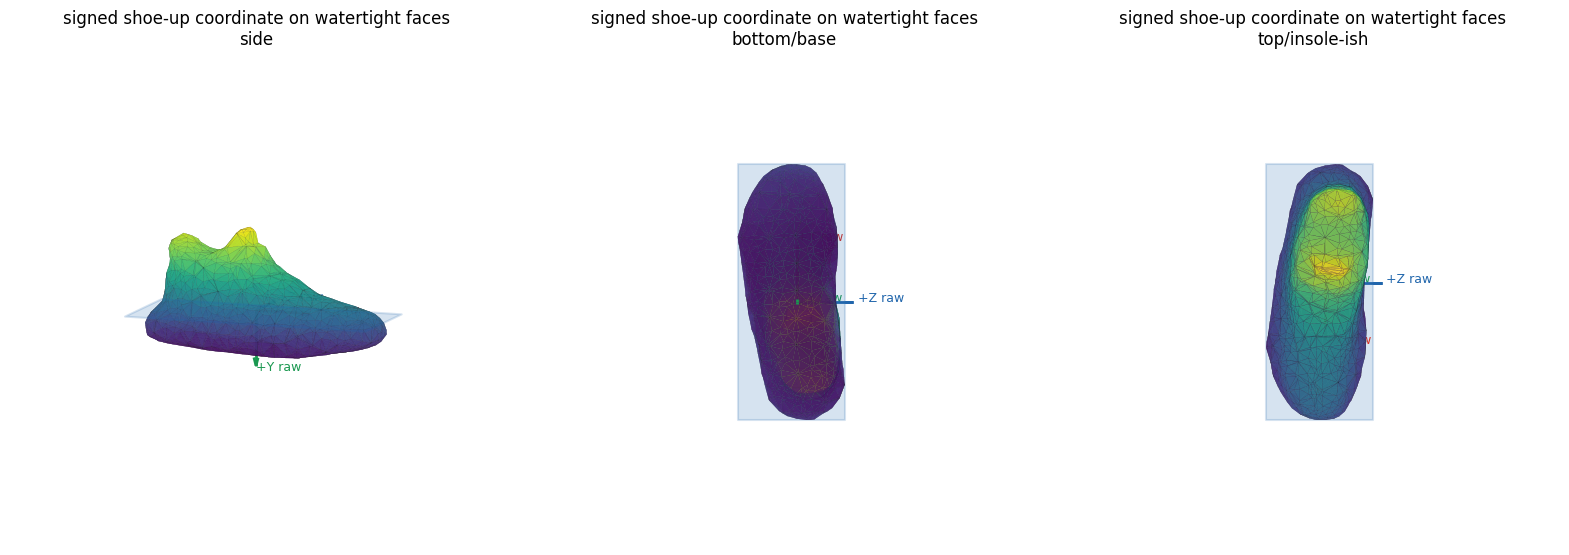

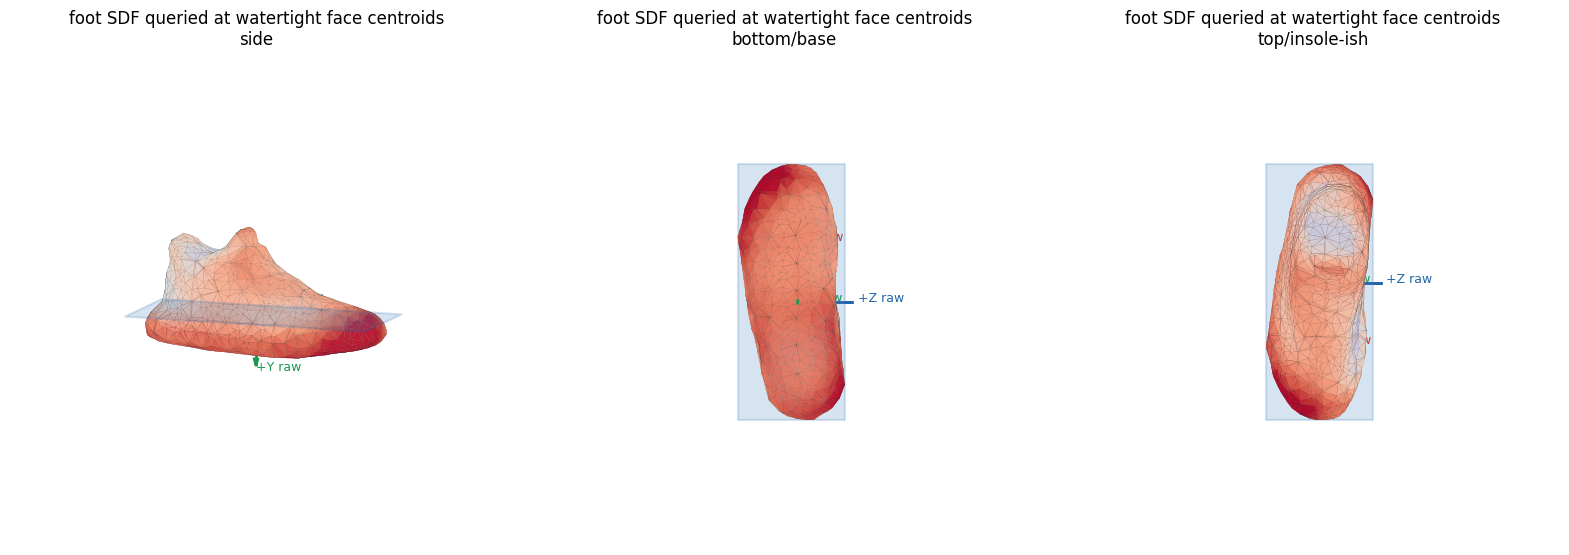

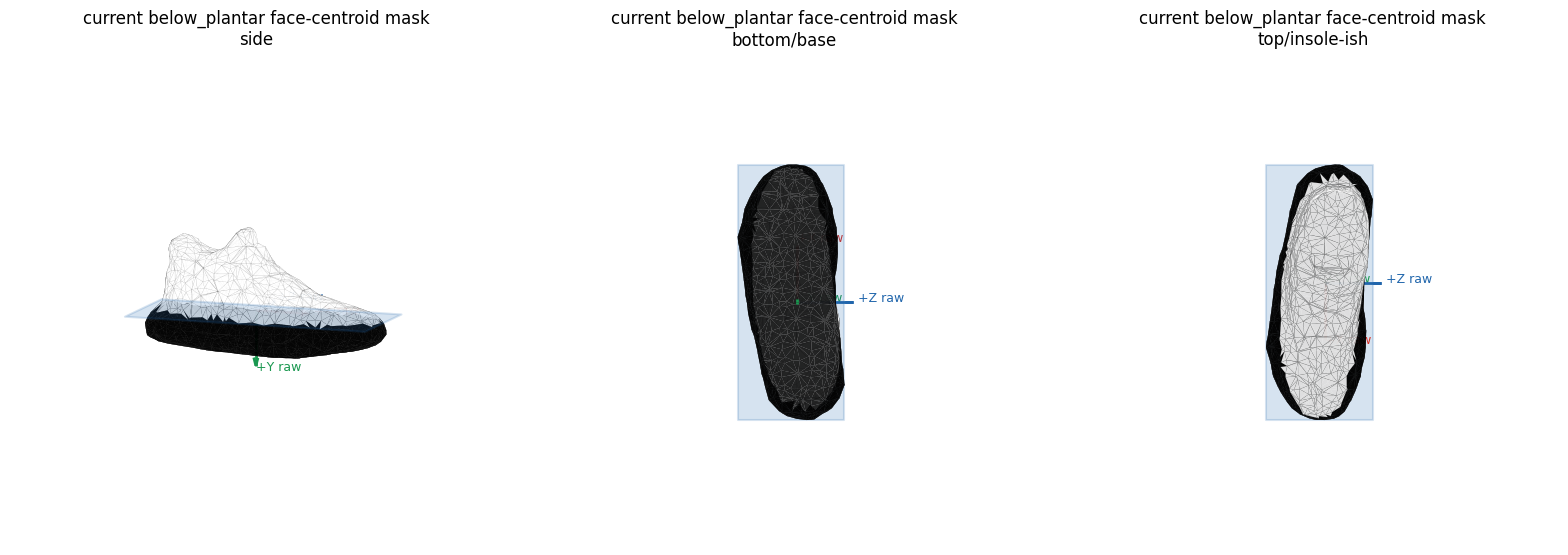

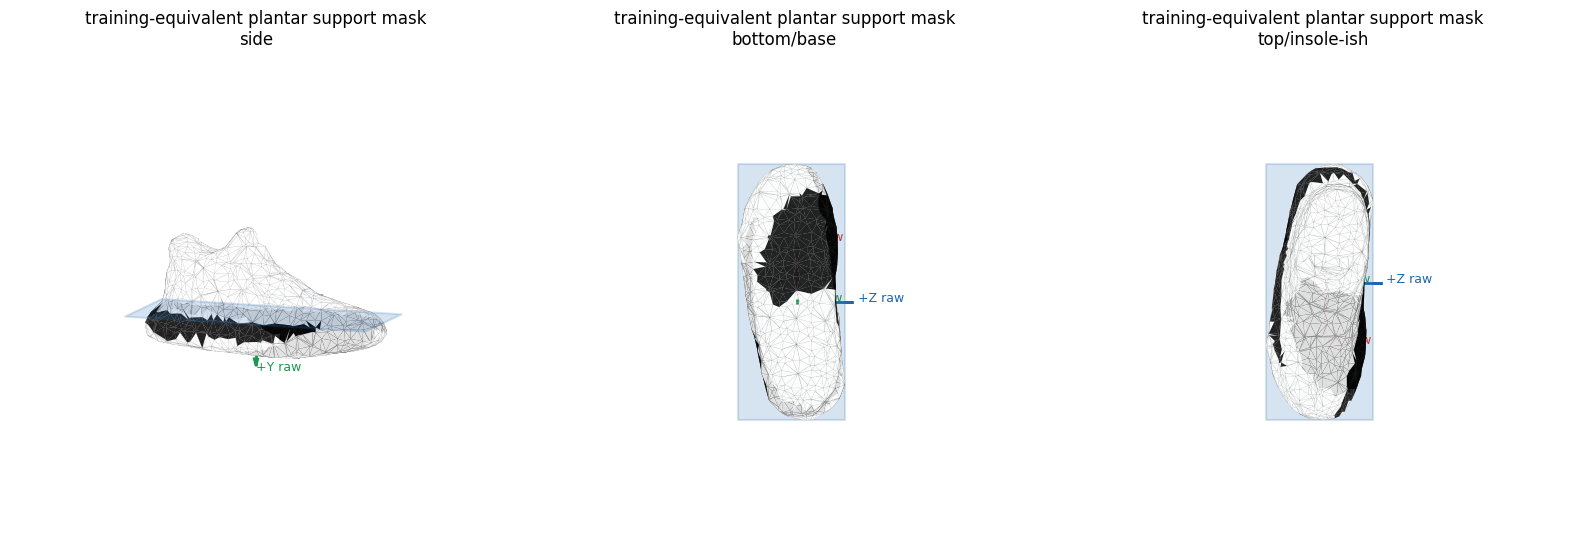

In [14]:
vertex_signed_up = sole_debug["vertex_signed_up"]
vertex_sdf = sole_debug["vertex_sdf"]
face_signed_up = sole_debug["centroid_signed_up"]
face_sdf = sole_debug["centroid_sdf"]
face_below = sole_debug["face_below_plantar"].astype(np.float32)
face_support = sole_debug["face_plantar_support"].astype(np.float32)

plot_watertight_scalar(
    "signed shoe-up coordinate on watertight faces",
    face_signed_up,
    cmap="viridis",
    norm=normalize_scalar(face_signed_up),
)
plot_watertight_scalar(
    "foot SDF queried at watertight face centroids",
    face_sdf,
    cmap="coolwarm",
    norm=normalize_scalar(face_sdf, center=0.0),
)
plot_watertight_scalar(
    "current below_plantar face-centroid mask",
    face_below,
    cmap="gray_r",
    norm=colors.Normalize(vmin=0.0, vmax=1.0),
)
plot_watertight_scalar(
    "training-equivalent plantar support mask",
    face_support,
    cmap="gray_r",
    norm=colors.Normalize(vmin=0.0, vmax=1.0),
)


### Optional Debug PLY Export

These PLYs are only for visual inspection in MeshLab/Blender. They do not affect training.


In [15]:
def values_to_uint8_colors(values, cmap="viridis", norm=None):
    values = np.asarray(values, dtype=np.float32)
    if norm is None:
        norm = normalize_scalar(values)
    return np.clip(cm.get_cmap(cmap)(norm(values))[:, :3] * 255.0, 0, 255).astype(np.uint8)


def mask_vertex_colors(mask, selected=(215, 48, 39), base=(185, 185, 185)):
    mask = np.asarray(mask, dtype=bool)
    out = np.full((mask.shape[0], 3), base, dtype=np.uint8)
    out[mask] = selected
    return out


def mesh_from_face_mask(mesh, face_mask):
    face_mask = np.asarray(face_mask, dtype=bool)
    faces = mesh.faces[face_mask]
    if faces.shape[0] == 0:
        return MeshData(mesh.vertices[:0].copy(), faces.copy())
    used = np.unique(faces.reshape(-1))
    remap = np.full(mesh.vertices.shape[0], -1, dtype=np.int64)
    remap[used] = np.arange(used.shape[0], dtype=np.int64)
    return MeshData(mesh.vertices[used].copy(), remap[faces])


height_colors = values_to_uint8_colors(sole_debug["vertex_signed_up"], cmap="viridis")
write_colored_ply(OUT_DIR / "watertight_height_debug.ply", watertight_mesh, height_colors)
write_colored_ply(
    OUT_DIR / "watertight_below_plantar_vertices.ply",
    watertight_mesh,
    mask_vertex_colors(sole_debug["vertex_below_plantar"]),
)

below_face_mesh = mesh_from_face_mask(watertight_mesh, sole_debug["face_below_plantar"])
support_face_mesh = mesh_from_face_mask(watertight_mesh, sole_debug["face_plantar_support"])
write_colored_ply(
    OUT_DIR / "watertight_below_plantar_faces.ply",
    below_face_mesh,
    np.full((below_face_mesh.vertices.shape[0], 3), [215, 48, 39], dtype=np.uint8),
)
write_colored_ply(
    OUT_DIR / "watertight_plantar_support_faces.ply",
    support_face_mesh,
    np.full((support_face_mesh.vertices.shape[0], 3), [49, 163, 84], dtype=np.uint8),
)

for path in [
    OUT_DIR / "watertight_height_debug.ply",
    OUT_DIR / "watertight_below_plantar_vertices.ply",
    OUT_DIR / "watertight_below_plantar_faces.ply",
    OUT_DIR / "watertight_plantar_support_faces.ply",
]:
    print("wrote", path)


wrote /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/foot_prior_debug/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids/watertight_height_debug.ply
wrote /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/foot_prior_debug/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids/watertight_below_plantar_vertices.ply
wrote /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/foot_prior_debug/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids/watertight_below_plantar_faces.ply
wrote /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/foot_prior_debug/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids/watertight_plantar_support_faces.ply


/tmp/ipykernel_1891946/3691153698.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  return np.clip(cm.get_cmap(cmap)(norm(values))[:, :3] * 255.0, 0, 255).astype(np.uint8)


## 8. Interactive Alignment

This is the important cell. Move the foot until it looks anatomically plausible inside the shoe.

The default now automatically rotates the foot to the shoe's principal horizontal axis. The `yaw` slider is an offset on top of that automatic yaw, so use small values first.

The two most important sliders are usually:

- `length`: how much of the shoe length the foot should occupy. Smaller values usually look more realistic because the mesh is the outer shoe, not the inner cavity.
- `plantar`: how high above the outsole bottom the plantar surface sits. This should usually be near the insole/midsole level, not the absolute bottom of the sole.


In [16]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    length_w = widgets.FloatSlider(value=0.78, min=0.65, max=0.98, step=0.01, description="length")
    scale_w = widgets.FloatSlider(value=1.0, min=0.75, max=1.20, step=0.01, description="scale")
    plantar_w = widgets.FloatSlider(value=0.032, min=0.004, max=0.040, step=0.002, description="plantar")
    auto_yaw_w = widgets.Checkbox(value=True, description="auto yaw")
    align_opening_w = widgets.Checkbox(value=True, description="ankle opening")
    tx_w = widgets.FloatSlider(value=0.0, min=-0.08, max=0.08, step=0.002, description="tx")
    ty_w = widgets.FloatSlider(value=0.0, min=-0.08, max=0.08, step=0.002, description="ty")
    tz_w = widgets.FloatSlider(value=0.0, min=-0.05, max=0.05, step=0.002, description="tz")
    yaw_w = widgets.FloatSlider(value=0.0, min=-35.0, max=35.0, step=1.0, description="yaw+/-")
    pitch_w = widgets.FloatSlider(value=0.0, min=-25.0, max=25.0, step=1.0, description="pitch")
    roll_w = widgets.FloatSlider(value=0.0, min=-25.0, max=25.0, step=1.0, description="roll")
    elev_w = widgets.IntSlider(value=10, min=-5, max=60, step=1, description="elev")
    azim_w = widgets.IntSlider(value=-70, min=-180, max=180, step=5, description="azim")
    show_shell_w = widgets.Checkbox(value=True, description="shell")
    show_watertight_w = widgets.Checkbox(value=True, description="watertight")
    out = widgets.Output()

    def current_alignment():
        return make_alignment(
            length_ratio=length_w.value,
            scale_multiplier=scale_w.value,
            plantar_clearance=plantar_w.value,
            auto_yaw=auto_yaw_w.value,
            align_ankle_to_opening=align_opening_w.value,
            yaw_degrees=yaw_w.value,
            pitch_degrees=pitch_w.value,
            roll_degrees=roll_w.value,
            tx=tx_w.value,
            ty=ty_w.value,
            tz=tz_w.value,
        )

    def redraw(_=None):
        aln = current_alignment()
        with out:
            clear_output(wait=True)
            print(f"scale={aln.scale:.5f}, plantar_z={aln.plantar_z:.5f}")
            print(f"auto_yaw={aln.auto_yaw_degrees:.2f} deg, yaw_offset={yaw_w.value:.1f} deg")
            print(f"ankle opening alignment = {align_opening_w.value}; opening center = {aln.opening_center}")
            print(f"length_ratio={length_w.value:.2f}, plantar_clearance={plantar_w.value:.3f}")
            print(f"translation offset = [{tx_w.value:.3f}, {ty_w.value:.3f}, {tz_w.value:.3f}]")
            print(f"pitch/roll = [{pitch_w.value:.1f}, {roll_w.value:.1f}] degrees")
            plot_alignment(
                aln,
                elev=elev_w.value,
                azim=azim_w.value,
                show_shell=show_shell_w.value,
                show_watertight=show_watertight_w.value,
                title="interactive foot alignment",
            )

    controls = widgets.VBox([
        widgets.HBox([length_w, scale_w, plantar_w, auto_yaw_w, align_opening_w]),
        widgets.HBox([tx_w, ty_w, tz_w]),
        widgets.HBox([yaw_w, pitch_w, roll_w]),
        widgets.HBox([elev_w, azim_w, show_shell_w, show_watertight_w]),
    ])
    for w in [length_w, scale_w, plantar_w, auto_yaw_w, align_opening_w, tx_w, ty_w, tz_w, yaw_w, pitch_w, roll_w, elev_w, azim_w, show_shell_w, show_watertight_w]:
        w.observe(redraw, names="value")
    display(controls, out)
    redraw()
except Exception as exc:
    print("ipywidgets are not available here; use make_alignment(...) manually above.")
    print(type(exc).__name__ + ":", exc)


Output()

## 9. Export Diagnostic Outputs

This writes the same kind of files as the script:

- `alignment.json`
- `foot_aligned.obj`
- `shoe_regions.ply`
- `watertight_regions.ply`
- `hybrid_shell_foot_retained.obj`

The hybrid mesh is the current shell plus watertight triangles whose centroids are below the plantar band.


In [17]:
# If the interactive cell above has been run, this uses the current slider values.
# Otherwise it falls back to the default automatic alignment.
if "current_alignment" in globals():
    export_alignment = current_alignment()
else:
    export_alignment = make_alignment(
        scale_multiplier=1.0,
        tx=0.0,
        ty=0.0,
        tz=0.0,
        yaw_degrees=0.0,
        pitch_degrees=0.0,
        roll_degrees=0.0,
    )

OUT_DIR.mkdir(parents=True, exist_ok=True)
ankle_loop = export_alignment.transform_foot_to_shoe(foot_mesh.vertices[get_single_boundary_loop(foot_mesh)])
shell_regions, watertight_regions = classify_shoe_points(shell_mesh.vertices, foot_sdf, export_alignment, ankle_loop), classify_shoe_points(watertight_mesh.vertices, foot_sdf, export_alignment, ankle_loop)
foot_aligned = export_alignment.transform_foot_to_shoe(foot_mesh.vertices)
retained = select_faces_below_signed_axis(
    watertight_mesh,
    axis=export_alignment.config.shoe_up_axis,
    axis_direction=export_alignment.config.shoe_up_sign,
    plantar_value=export_alignment.plantar_z,
    band=export_alignment.config.plantar_band,
)
hybrid = make_hybrid_mesh(shell_mesh, watertight_mesh, retained)

export_alignment.save_json(OUT_DIR / "alignment.json")
write_obj_mesh(OUT_DIR / "foot_aligned.obj", MeshData(foot_aligned, foot_mesh.faces))
write_colored_ply(OUT_DIR / "shoe_regions.ply", shell_mesh, colors_from_regions(shell_regions))
write_colored_ply(OUT_DIR / "watertight_regions.ply", watertight_mesh, colors_from_regions(watertight_regions))
write_obj_mesh(OUT_DIR / "hybrid_shell_foot_retained.obj", hybrid)

summary = {
    "alignment": export_alignment.to_dict(),
    "shell_regions": region_summary(shell_regions),
    "watertight_regions": region_summary(watertight_regions),
    "retained_watertight_faces": int(retained.sum()),
    "total_watertight_faces": int(retained.shape[0]),
}
with (OUT_DIR / "summary_from_notebook.json").open("w") as f:
    json.dump(summary, f, indent=2)
    f.write("\n")

print("wrote", OUT_DIR)
print(json.dumps(summary, indent=2)[:1800])


wrote /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/foot_prior_debug/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids
{
  "alignment": {
    "foot_to_shoe": [
      [
        -0.09607548266649246,
        0.0,
        0.8292011022567749,
        -0.03869783505797386
      ],
      [
        0.0,
        -0.8347484469413757,
        0.0,
        -1.091460943222046
      ],
      [
        0.8292011022567749,
        0.0,
        0.09607548266649246,
        0.08957283198833466
      ],
      [
        0.0,
        0.0,
        0.0,
        1.0
      ]
    ],
    "shoe_to_foot": [
      [
        -0.13788002729415894,
        0.0,
        1.190004587173462,
        -0.11192774027585983
      ],
      [
        -0.0,
        -1.1979657411575317,
        -0.0,
        -1.307532787322998
      ],
      [
        1.190004587173462,
        0.0,
        0.13788002729415894,
        0.03370029851794243
      ],
      [
        0.0,
        0.0,
        0.0,
        1